<a href="https://colab.research.google.com/github/hanidew/G12_IR_Evaluation/blob/Correlation-Coefficient-Analysis/IRWS_Correlation_Coefficient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Phase 3: Correlation Coefficient Analysis
**Objective:** Determine if the 15 retrieval systems finish in the same ranking order regardless of the evaluation metric used.

**Methodology:**
- To determine the similarity of system performance rankings across different evaluation metrics, we utilized the Kendall’s Tau ($\tau$) rank correlation coefficient.
- We specifically selected this method over Pearson's correlation because our primary goal is to measure ordinal association, whether the final leaderboard positions remain identical, rather than evaluating exact numerical score gaps.
- We chose Kendall's Tau over Spearman’s rank because it calculates the direct probability of concordant pairs (where System A consistently ranks above System B).
- This concordant pair calculation makes Kendall's Tau the most robust and accurate measure of system ranking stability for Information Retrieval.

We will generate a Correlation Matrix (Heatmap) to visually analyze:
1. **Stability:** Does a system ranking well at depth 5 also rank well at depth 10?
2. **Similarity:** Does standard Precision (P) agree with Mean Average Precision (MAP) at the same depth?
3. **Ultimate Predictors:** Can shallow evaluations (P@10) accurately predict deep system quality (MAP@1000)?

========== CORRELATION RESULTS (KENDALL'S TAU) ==========
P@5 vs P@10:
  Correlation (τ) = 0.7670
  P-value = 0.0001

MAP@10 vs MAP@100:
  Correlation (τ) = 0.6952
  P-value = 0.0001

P@5 vs MAP@5:
  Correlation (τ) = 0.6184
  P-value = 0.0015

P@10 vs MAP@10:
  Correlation (τ) = 0.6124
  P-value = 0.0015

P@100 vs MAP@100:
  Correlation (τ) = 0.6190
  P-value = 0.0008

P@5 vs MAP@1000:
  Correlation (τ) = 0.6957
  P-value = 0.0003

P@10 vs MAP@1000:
  Correlation (τ) = 0.7273
  P-value = 0.0002



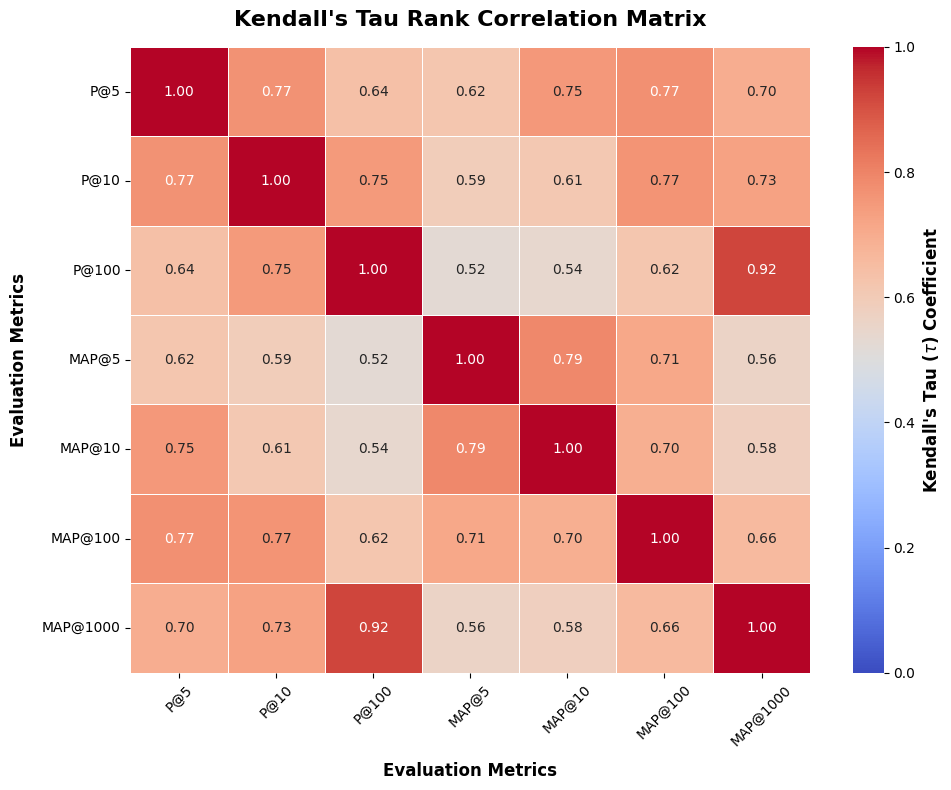

In [8]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. SET FOLDER PATH ---
folder_path = '/content/drive/MyDrive/IRWS/set12/'

# --- 2. LOAD THE FILES ---
# Load Joan's Mean Precision scores
df_p = pd.read_csv(folder_path + 'Mean_Precision_per_System.csv', index_col=0)
# Ensure column names are strings so we can rename them easily
df_p.columns = [str(col) for col in df_p.columns]
df_p = df_p.rename(columns={'5': 'P@5', '10': 'P@10', '20': 'P@20', '50': 'P@50', '100': 'P@100'})

# Load Steffi's MAP scores
df_map = pd.read_csv(folder_path + 'MAP@k_per_System.csv', index_col='system_name')

# --- 3. MERGE THE DATA ---
# Combine both tables so we have all metrics for all 15 systems in one place
df_combined = pd.concat([df_p, df_map], axis=1)

# --- 4. CALCULATE KENDALL'S TAU CORRELATION ---
pairs_to_test = [
    # Category 1: Same Metric, Different Depth (Stability)
    ('P@5', 'P@10'),
    ('MAP@10', 'MAP@100'),

    # Category 2: Different Metric, Same Depth (Similarity)
    ('P@5', 'MAP@5'),
    ('P@10', 'MAP@10'),
    ('P@100', 'MAP@100'),

    # Category 3: Shallow vs Deep True Quality
    ('P@5', 'MAP@1000'),
    ('P@10', 'MAP@1000')
]

print("========== CORRELATION RESULTS (KENDALL'S TAU) ==========")
for metric1, metric2 in pairs_to_test:
    # Calculate Kendall's Tau rank correlation
    tau, p_val = stats.kendalltau(df_combined[metric1], df_combined[metric2])
    print(f"{metric1} vs {metric2}:")
    print(f"  Correlation (\u03c4) = {tau:.4f}")
    print(f"  P-value = {p_val:.4f}\n")

# --- 5. VISUALIZATION: THE ULTIMATE MATRIX ---
# We select a strong mix of shallow and deep metrics to show in the final heatmap
metrics_for_heatmap = ['P@5', 'P@10', 'P@100', 'MAP@5', 'MAP@10', 'MAP@100', 'MAP@1000']
corr_matrix = df_combined[metrics_for_heatmap].corr(method='kendall')

# Set up the visual look of the chart
plt.figure(figsize=(10, 8))

# Create heatmap and add the Color Bar Legend
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': r"Kendall's Tau ($\tau$) Coefficient"} # <-- COLOR BAR LABEL ADDED HERE
)

# Adjust the font size of the color bar label to make it readable
ax.figure.axes[-1].yaxis.label.set_size(12)
ax.figure.axes[-1].yaxis.label.set_weight('bold')

# Add Titles and Labels
plt.title("Kendall's Tau Rank Correlation Matrix", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Evaluation Metrics", fontsize=12, fontweight='bold', labelpad=10) # <-- X-AXIS LABEL ADDED HERE
plt.ylabel("Evaluation Metrics", fontsize=12, fontweight='bold', labelpad=10) # <-- Y-AXIS LABEL ADDED HERE

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Save the chart directly to the shared Google Drive folder!
# output_image_path = folder_path + 'Correlation_Heatmap.png'
# plt.savefig(output_image_path)
plt.show()

# print(f"\n Heatmap image successfully saved to: {output_image_path}")

### Key Takeaways from the Heatmap

* **Deep Quality Predictors:** The exceptionally high correlation between `P@100` and `MAP@1000` ($\tau = 0.92$) shows that retrieving relevant documents in the top 100 almost perfectly mirrors the final 1,000-document leaderboard. Even `P@10` ($\tau = 0.73$) serves as a strong, reliable predictor of overall system quality.
* **Precision vs. Ranking Variance:** The moderate correlation between `P@10` and `MAP@10` ($\tau = 0.61$) highlights that finding relevant documents (Precision) is a distinctly different skill than ranking those exact documents perfectly at Rank 1 or 2 (MAP).
* **Shallow Stability:** The strong correlation between `P@5` and `P@10` ($\tau = 0.77$) proves that systems providing highly relevant results in their top 5 naturally continue that performance through their top 10.
* **General Consistency:** All evaluated metrics display positive correlations, confirming that top-performing algorithms are highly robust and maintain their dominant leaderboard positions regardless of the evaluation lens applied.